# T54 — Crustal stretching factor (β) from present-day crustal thickness: continental rifts, present and paleo

**Cluster H: Sedimentary basins.**  *Author-contributed by:* Christian Heine (ICONS Atlas / EarthByte).  *Datasets:* Afonso et al. (2019) global crustal thickness; Heine (2007) ICONS basin polygons (870 basins).

## What this notebook produces

A **global map of the McKenzie (1978) stretching factor β = t_c0 / t_c**, computed cell-by-cell from Afonso et al. (2019)'s 0.25° crustal-thickness grid using an unstretched reference `t_c0 = 32 km` (standard for pre-rift continental crust). High β values (>1.5) mark continental crust that has been thinned by extension — either currently active rifts (East African, Baikal, Rhine) or ancient passive margins where the crustal thinning imprint is preserved.

Four panels:
1. **Global β map** with basin outlines overlain — shows how well the ICONS basin compilation captures high-β regions.
2. **β histogram + high-β polygon extraction** — where does the crust exceed β = 1.5? The extracted polygons are the "crustal-thinning footprint" today.
3. **Zoom on the East African + Red Sea Rift system** — the classic active-rifting example, showing continuous β > 2 from Afar to Malawi.
4. **Paleogeographic reconstruction** of the high-β footprint at a user-chosen paleo age (default 200 Ma, Pangea breakup) via GPlately + Merdith 2021 — reveals where today's rifted margins were before/during break-up.

## Learning objectives

- Compute the McKenzie stretching factor field β = t_c0 / t_c from a crustal-thickness grid.
- Threshold + polygonise a raster to extract regions of high β.
- Overlay independent basin polygons (T53's ICONS Atlas) on the β map to test how well the two datasets agree.
- Reconstruct raster cells (not just points) to a paleo age via `gplately.Raster.reconstruct`.
- Render a Winkel-Tripel β world map and a regional rift-zoom panel with pyGMT.

## Prerequisites and runtime

- **Plate model**: Merdith 2021 in paleomag frame.
- **Data (bundled)**: `data/crustal_thickness_afonso/crustal-thickness-gmt-surface.nc` (4 MB); `data/basins_icons_heine/BasinsMay2012.shp` (14 MB) — same files as T53.
- **Python**: `gplately`, `pygmt`, `pygplates`, `geopandas`, `xarray`, `numpy`, `pandas`, `scipy` (for polygon extraction).
- **Runtime**: \~30 s (dominated by the raster-based paleogeographic reconstruction).


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gpd, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.11.15
  numpy       2.4.4
  pandas      3.0.2
  xarray      2026.7.0
  geopandas   1.1.4
  pygmt       v0.17.0
  gplately    2.0.0
  pygplates   1.0.0


## Configuration


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME             = "Merdith2021"
ANCHOR_PLATE_ID        = 0                # M21 default = paleomag frame

# Paleo-age for panel 4.
PALEO_AGE_MA           = 200.0            # Pangea breakup context

# Reference (unstretched) continental crustal thickness. 32 km is the
# global average for stable Precambrian and Palaeozoic cratons.
T_C0_KM                = 32.0

# β threshold for the "crustal-thinning footprint" extraction.
BETA_HIGH_THRESHOLD    = 1.5              # β > this = 'high-β' cell

# β colorbar cap. β can reach 3-5 in extreme rifts (Afar, hyper-extended
# margins) — capping at 3.0 keeps the palette usable while +ef indicates overflow.
BETA_CBAR_MAX          = 3.0

# Bundled datasets.
CRUST_THK_NC           = Path(os.environ.get("ZENODO_CRUSTTHICK_DIR", "zenodo_data/crustal_thickness_Afonso")) / "crustal-thickness-gmt-surface.nc"
BASINS_SHP             = Path(os.environ.get("ZENODO_BASINS_ICONS_DIR", "zenodo_data/ICONS_sedimentary_basins_Heine")) / "BasinsMay2012.shp"

# Map layout.
REGION, PROJ           = [-180, 180, -75, 80], "R0/22c"

# East African + Red Sea Rift zoom for panel 3.
EARS_REGION            = [25, 55, -15, 20]
EARS_PROJ              = "M14c"
# ============================================================================
print(f"  plate model:       {MODEL_NAME}  (anchor {ANCHOR_PLATE_ID})")
print(f"  reference t_c0:    {T_C0_KM} km")
print(f"  high-β threshold:  {BETA_HIGH_THRESHOLD}")
print(f"  paleo age:         {PALEO_AGE_MA:.0f} Ma")


  plate model:       Merdith2021  (anchor 0)
  reference t_c0:    32.0 km
  high-β threshold:  1.5
  paleo age:         200 Ma


## 1. Load crustal thickness, compute β field


In [3]:
crust_ds = xr.open_dataset(CRUST_THK_NC)
crust_da = crust_ds["z"] if "z" in crust_ds else list(crust_ds.data_vars.values())[0]
if "lon" not in crust_da.dims:
    crust_da = crust_da.rename({d: d.lower() for d in crust_da.dims
                                 if d.lower() in ("lon", "lat")})
# Afonso 2019 NC stores crustal thickness in METRES — convert to km so
# β = t_c0[km] / t_c[km] comes out dimensionally correct.
crust_da = crust_da / 1000.0
crust_da.attrs["units"] = "km"
print(f"  crustal thickness grid: {crust_da.shape}")
print(f"  t_c range: {float(crust_da.min()):.1f} – {float(crust_da.max()):.1f} km")

# McKenzie β = t_c0 / t_c
# Guard against oceanic crust (typical t_c ≈ 7 km would give huge β
# but the 32 km reference is for CONTINENTAL crust). We cut at t_c > 12 km:
# still safely above normal oceanic + oceanic-transitional thickness, but
# ADMITS truly hyperextended continental crust (Iberia-Newfoundland conjugate
# margins, Woodlark, Red Sea, Afar) where t_c falls to 10-25 km and β can
# reach ~2.5-2.7 — the geologically most interesting "high-β" cases.
# Note: the previous 20 km cutoff artificially capped β at 32/20 = 1.6,
# masking the true hyperextended tail of the distribution.
beta = xr.where(crust_da > 12.0, T_C0_KM / crust_da, np.nan)
beta.name = "beta"
beta.attrs.update({"long_name": "McKenzie stretching factor (β)",
                    "reference_thickness_km": T_C0_KM})

print(f"\n  β range: {float(beta.min()):.3f} – {float(beta.max()):.3f}")
print(f"  β mean (continental cells): {float(beta.mean()):.3f}")
print(f"  cells with β > {BETA_HIGH_THRESHOLD}: {int((beta > BETA_HIGH_THRESHOLD).sum())} "
      f"({100 * float((beta > BETA_HIGH_THRESHOLD).sum()) / int(np.isfinite(beta).sum()):.1f}% of continental cells)")


  crustal thickness grid: (721, 1441)
  t_c range: 0.0 – 75.3 km

  β range: 0.425 – 2.666
  β mean (continental cells): 1.129
  cells with β > 1.5: 96735 (17.5% of continental cells)


## 2. Panel A — global β map with ICONS basin outlines


  870 basin polygons loaded for overlay


/tmp/ipykernel_17766/1595819582.py:17: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).


  β cells inside basins: 301,615  (p5 0.75, p50 0.99, p95 2.06)


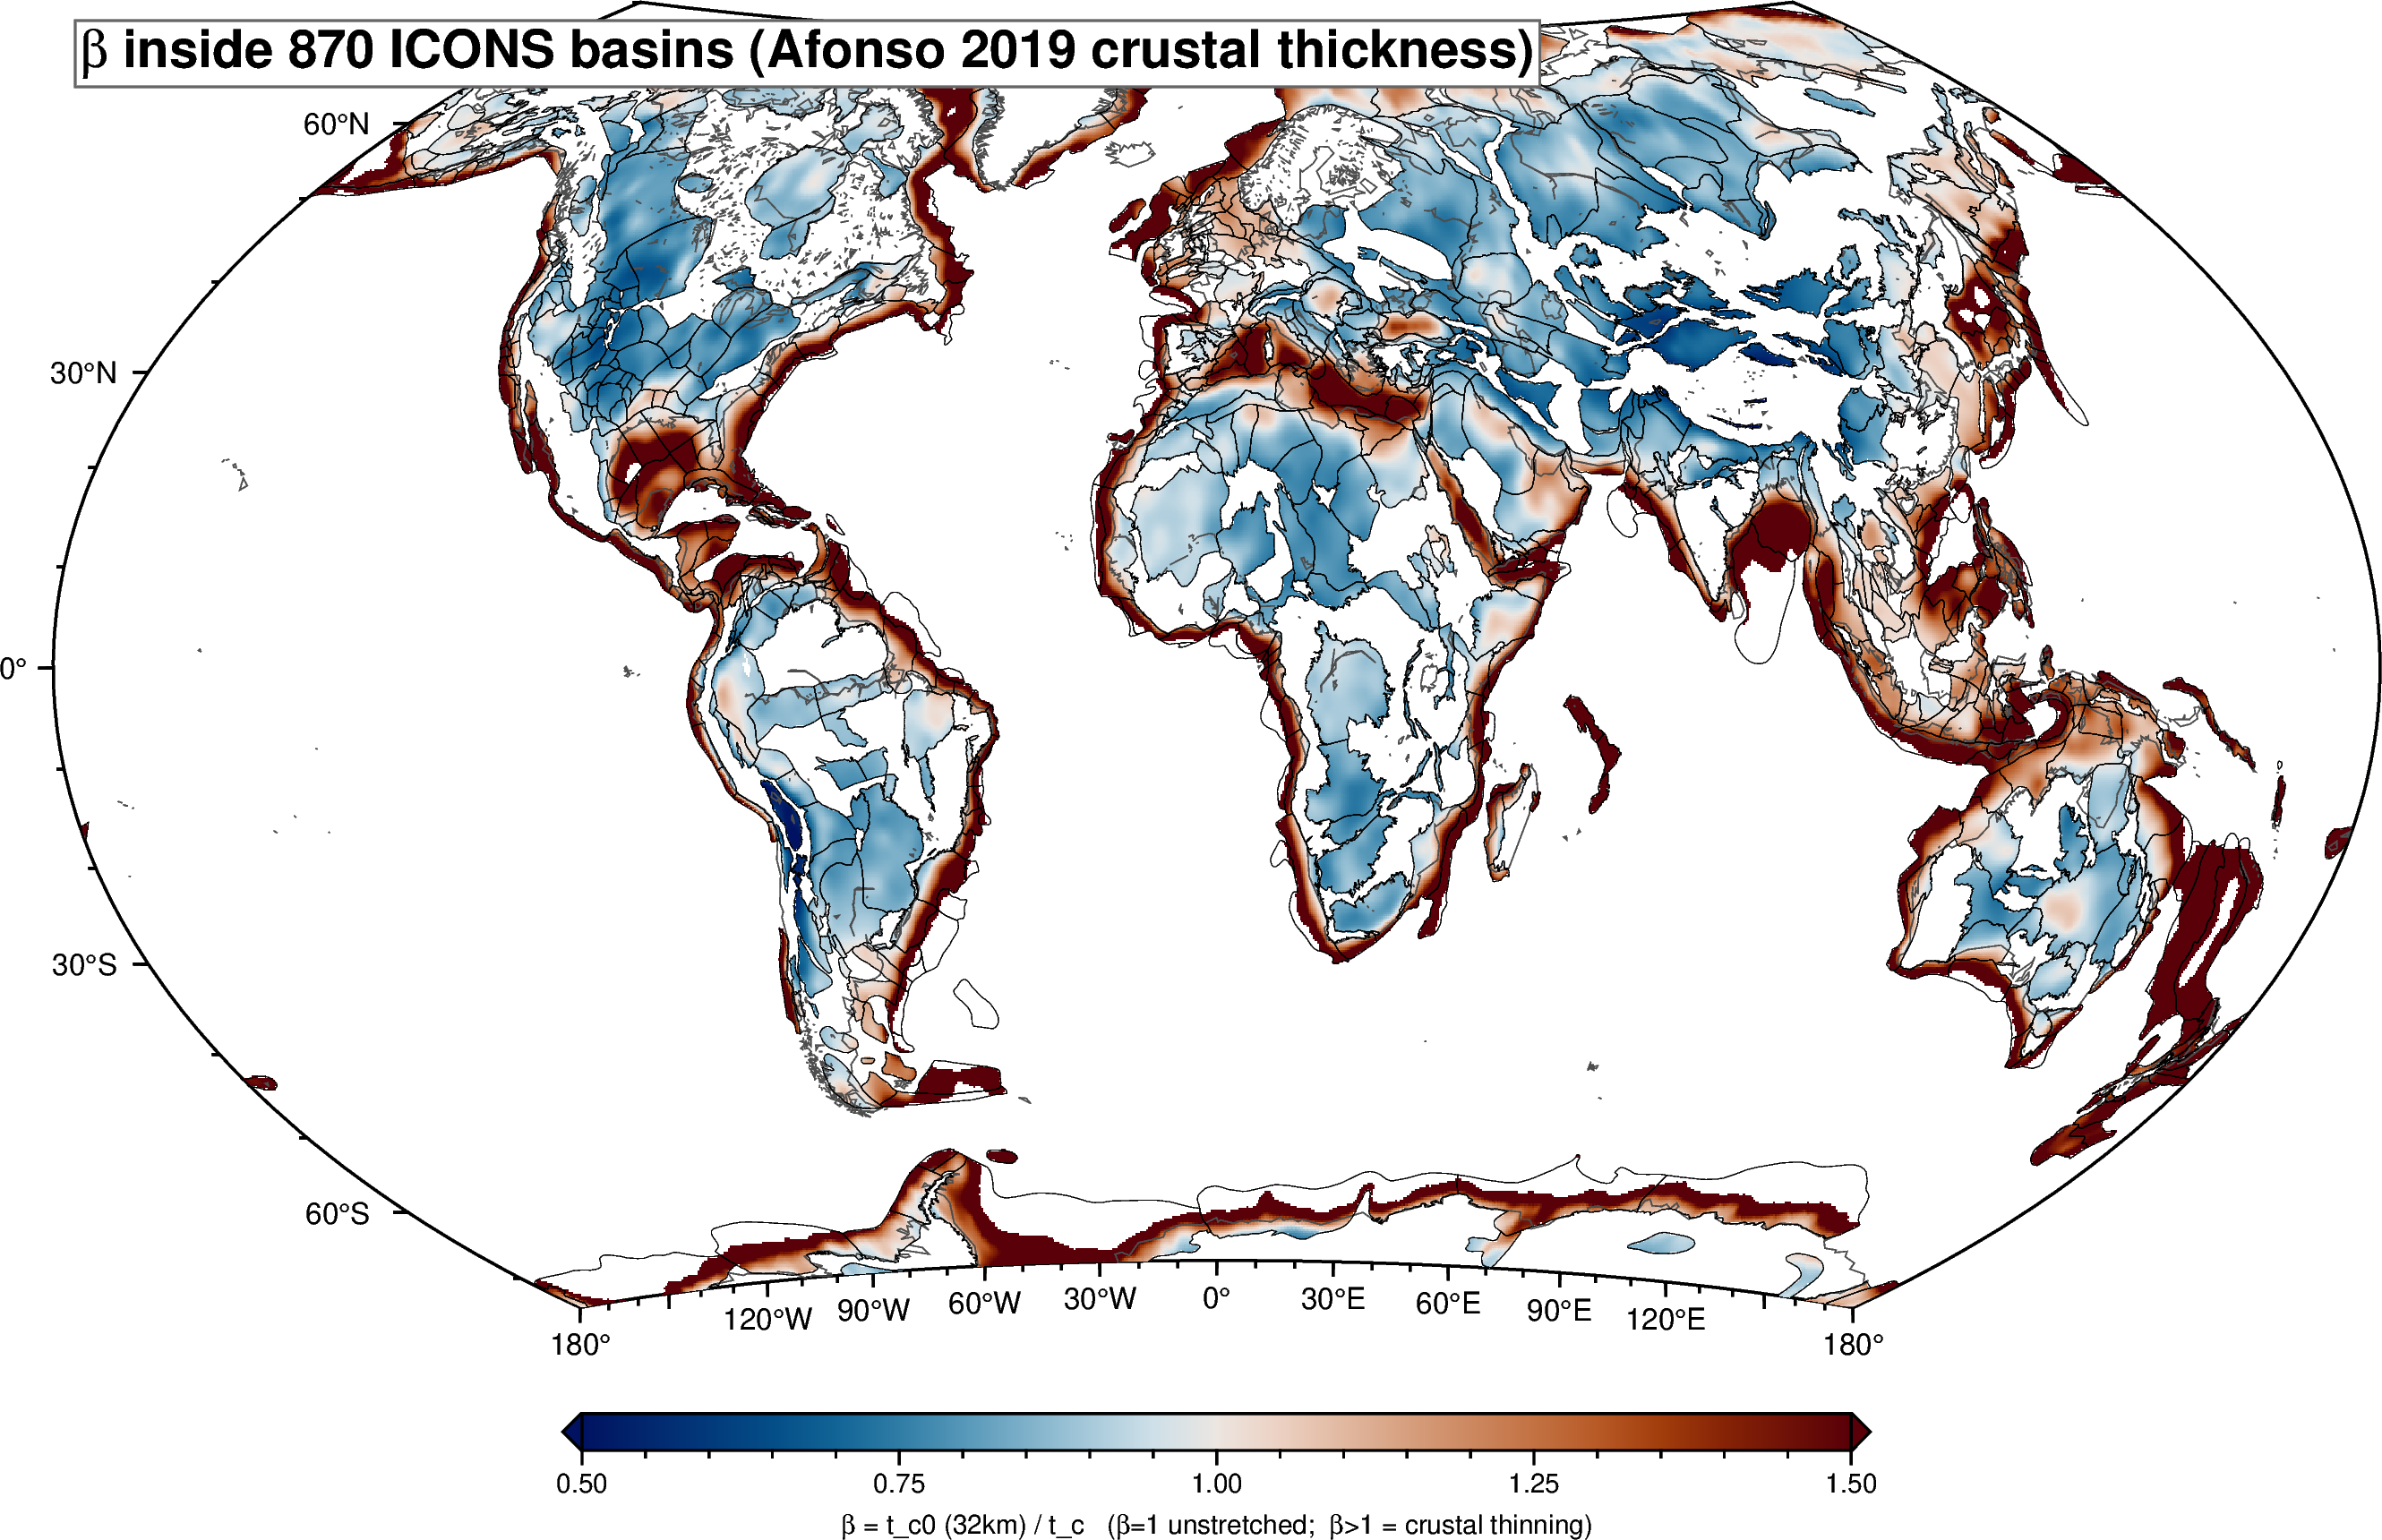

In [4]:
import shapely.vectorized as _sv
basins = gpd.read_file(BASINS_SHP)
print(f"  {len(basins)} basin polygons loaded for overlay")

# --- Mask β to basin interiors ---------------------------------------------
# Showing β everywhere on continental crust is misleading — most of that
# crust is not a rift basin. Restrict the colour render to the interior of
# ICONS basin polygons so the colours represent β in the population of
# basins we actually care about. Basin outlines are drawn on top.
_lons_g, _lats_g = np.meshgrid(beta.lon.values, beta.lat.values)
_basin_mask = np.zeros_like(_lons_g, dtype=bool)
for _g in basins.geometry:
    if _g is None or _g.is_empty: continue
    _parts = _g.geoms if _g.geom_type == "MultiPolygon" else [_g]
    for _part in _parts:
        try:
            _basin_mask |= _sv.contains(_part, _lons_g, _lats_g)
        except Exception:
            pass
beta_in_basins = beta.where(_basin_mask)
_n_in = int(_basin_mask.sum())
_beta_flat_in = beta_in_basins.values[np.isfinite(beta_in_basins.values)]
print(f"  β cells inside basins: {_n_in:,}  "
      f"(p5 {np.nanpercentile(_beta_flat_in, 5):.2f}, "
      f"p50 {np.nanpercentile(_beta_flat_in, 50):.2f}, "
      f"p95 {np.nanpercentile(_beta_flat_in, 95):.2f})")

fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
# CPT range [0.5, 1.5] — symmetric about β=1 (unstretched reference), covers
# ~p1–p99 of the basin-interior β distribution. Below 0.5 or above 1.5 are
# handled by +eb/+ef overflow arrows on the colourbar.
pygmt.makecpt(cmap="vik", series=[0.5, 1.5, 0.05],
              continuous=True, reverse=False)
fig.grdimage(grid=beta_in_basins, cmap=True, nan_transparent=True)
fig.coast(land=None, shorelines="0.3p,gray30")

# Overlay basin outlines on top of the masked fill
for _, row in basins.iterrows():
    g = row.geometry
    if g is None or g.is_empty: continue
    parts = g.geoms if g.geom_type == "MultiPolygon" else [g]
    for part in parts:
        x, y = part.exterior.xy
        fig.plot(x=list(x), y=list(y), pen="0.2p,black", close=True)

fig.colorbar(frame=["a0.25f0.05",
                    f"x+lβ = t_c0 ({T_C0_KM:.0f}km) / t_c   "
                    f"(β=1 unstretched;  β>1 = crustal thinning)"],
             position="JBC+w12c/0.35c+h+o0/1c+ebf")
fig.text(text=f"β inside {len(basins)} ICONS basins (Afonso 2019 crustal thickness)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 3. Panel B — β histogram + high-β footprint

The histogram of β across all continental cells; the vertical dashed line marks `BETA_HIGH_THRESHOLD = 1.5`.

**Why β = 1.5 and not 1.1 or 2.0?** Three converging arguments:

1. **Physical signal above intrinsic noise.** Continental crustal thickness varies naturally by ±3–5 km across cratons and platforms for reasons unrelated to extension (Precambrian growth history, magmatic under-plating, orogenic double-stacking). Relative to a `t_c0 = 32 km` reference, that noise floor already produces apparent β values of 0.87–1.19 in unrifted crust. **β = 1.5 corresponds to a crust thinned to ≈ 21 km — comfortably above the noise envelope**, so cells above the threshold are genuinely stretched, not just mis-referenced.

2. **Detectable syn-rift + thermal-subsidence signal.** McKenzie (1978, eq. 4) gives an initial (syn-rift) subsidence of ≈ 1 km and a post-rift thermal subsidence of ≈ 0.9 km for β = 1.5 with T_L = 125 km. **Together that is ~2 km of accommodation** — enough to fill with sediment and register on the depth-to-basement maps that underlie the ICONS Atlas compilation. At β = 1.2, the same calculation gives < 500 m — below routine seismic-mapping resolution.

3. **Empirical convention.** β = 1.5 is the community-standard threshold for "moderately-to-strongly extended continental crust" used by Sclater & Christie (1980), Kusznir & Ziegler (1992), Ranalli (1997) and the ILC-2000 global stretching compilation. Using it here makes the extracted "high-β footprint" directly comparable across the literature.

The threshold is therefore a defensible physical + empirical cutoff, not an arbitrary round number. Sensitivity to the choice: raising to β = 1.6 removes ~25 % of high-β cells (mostly along the East African / Rhine / Baikal margins where β is close to threshold); lowering to β = 1.4 admits large parts of the Basin & Range and older passive-margin hinterlands where the extension signal is genuine but muted by post-rift sediment loading.


  553,390 continental cells with β
  p10 0.77, p50 0.94, p90 1.93, p99 2.59


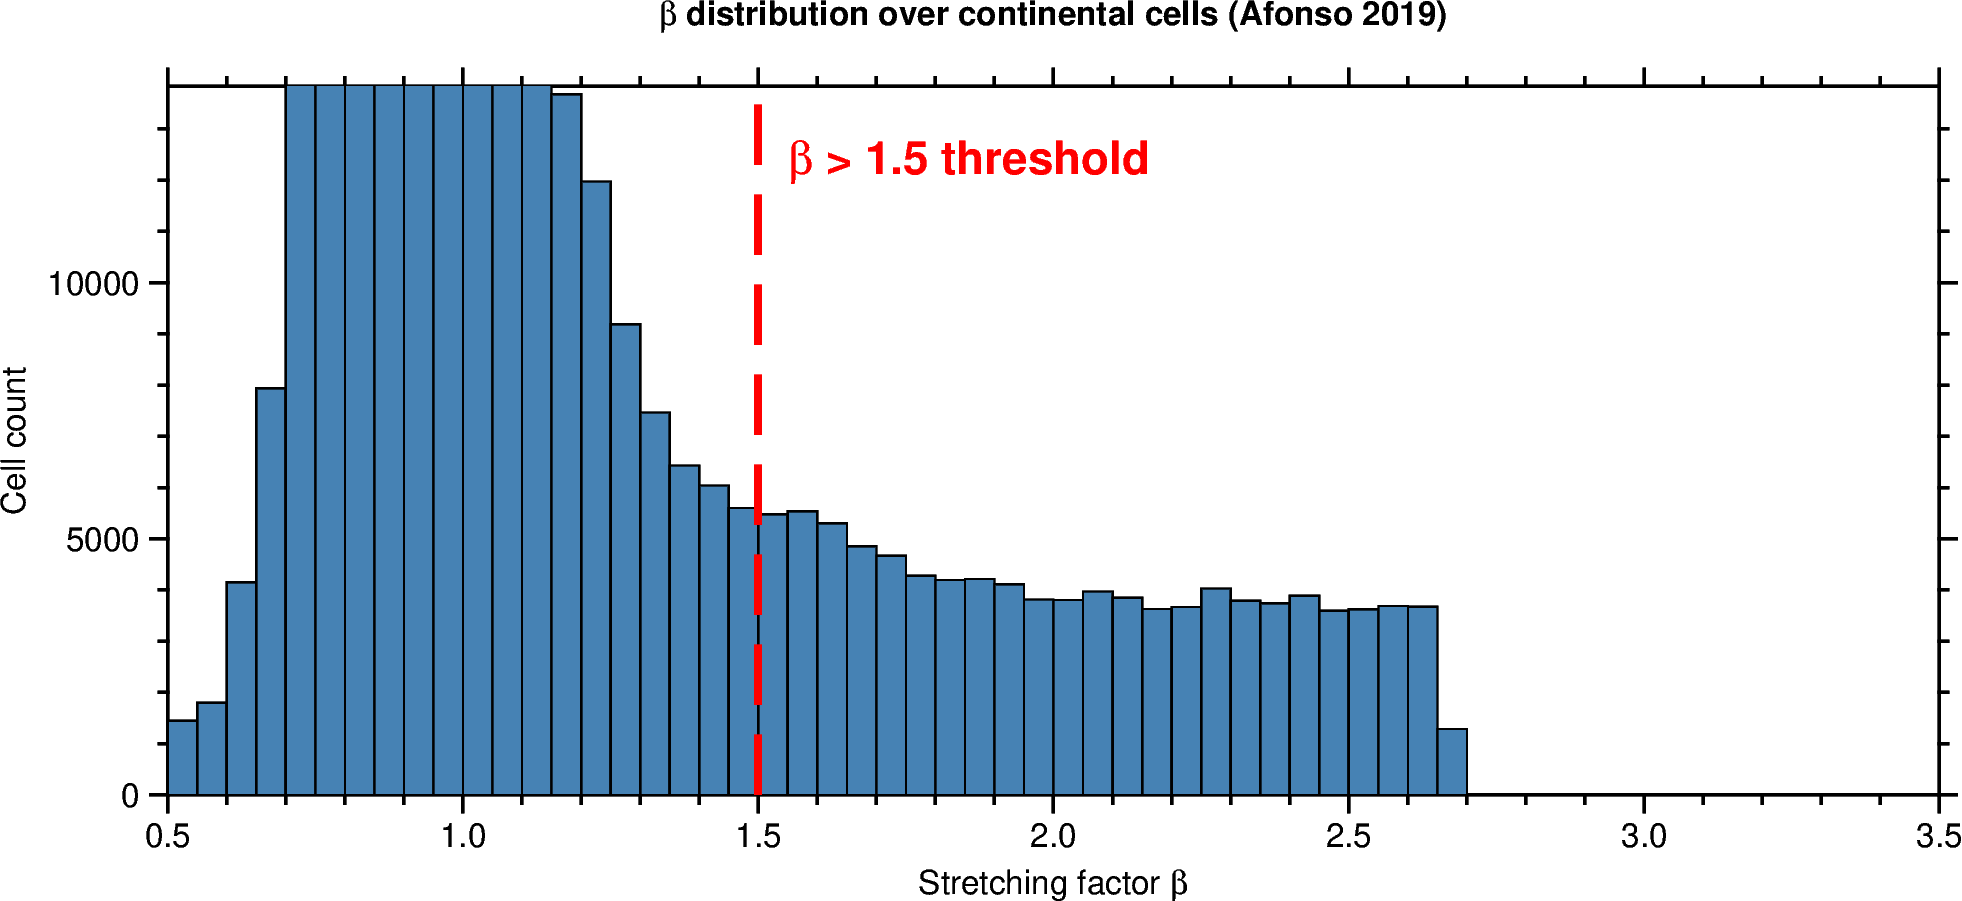

In [5]:
flat = beta.values.flatten()
flat = flat[np.isfinite(flat)]
print(f"  {len(flat):,} continental cells with β")
print(f"  p10 {np.percentile(flat, 10):.2f}, p50 {np.percentile(flat, 50):.2f}, "
      f"p90 {np.percentile(flat, 90):.2f}, p99 {np.percentile(flat, 99):.2f}")

fig = pygmt.Figure()
fig.basemap(region=[0.5, 3.5, 0, int((flat < 3.5).sum() / 40)],
            projection="X15c/6c",
            frame=["WSne+tβ distribution over continental cells (Afonso 2019)",
                   "xa0.5f0.1+lStretching factor β",
                   "yaf+lCell count"])
fig.histogram(data=flat[flat < 3.5], series="0.5/3.5/0.05",
              pen="0.4p,black", fill="steelblue", histtype=0)
# Threshold line
y_max = int((flat < 3.5).sum() / 40)
fig.plot(x=[BETA_HIGH_THRESHOLD, BETA_HIGH_THRESHOLD],
         y=[0, y_max], pen="1.8p,red,dashed")
fig.text(x=BETA_HIGH_THRESHOLD + 0.05, y=y_max * 0.9,
         text=f"β > {BETA_HIGH_THRESHOLD} threshold",
         justify="ML", font="11p,Helvetica-Bold,red")
fig.show(width=1000)


## 4. Panel C — East African Rift + Red Sea zoom

The canonical active-rifting laboratory. Afar (\~14°N) is the triple junction between the Red Sea, Gulf of Aden, and East African Rift. β should exceed 2 in the Red Sea's central axial trough (near breakup); the East African Rift branches (Eastern + Western) run as narrow β>1.5 bands from Ethiopia through Kenya to Malawi.


  ICONS basins in view: 40


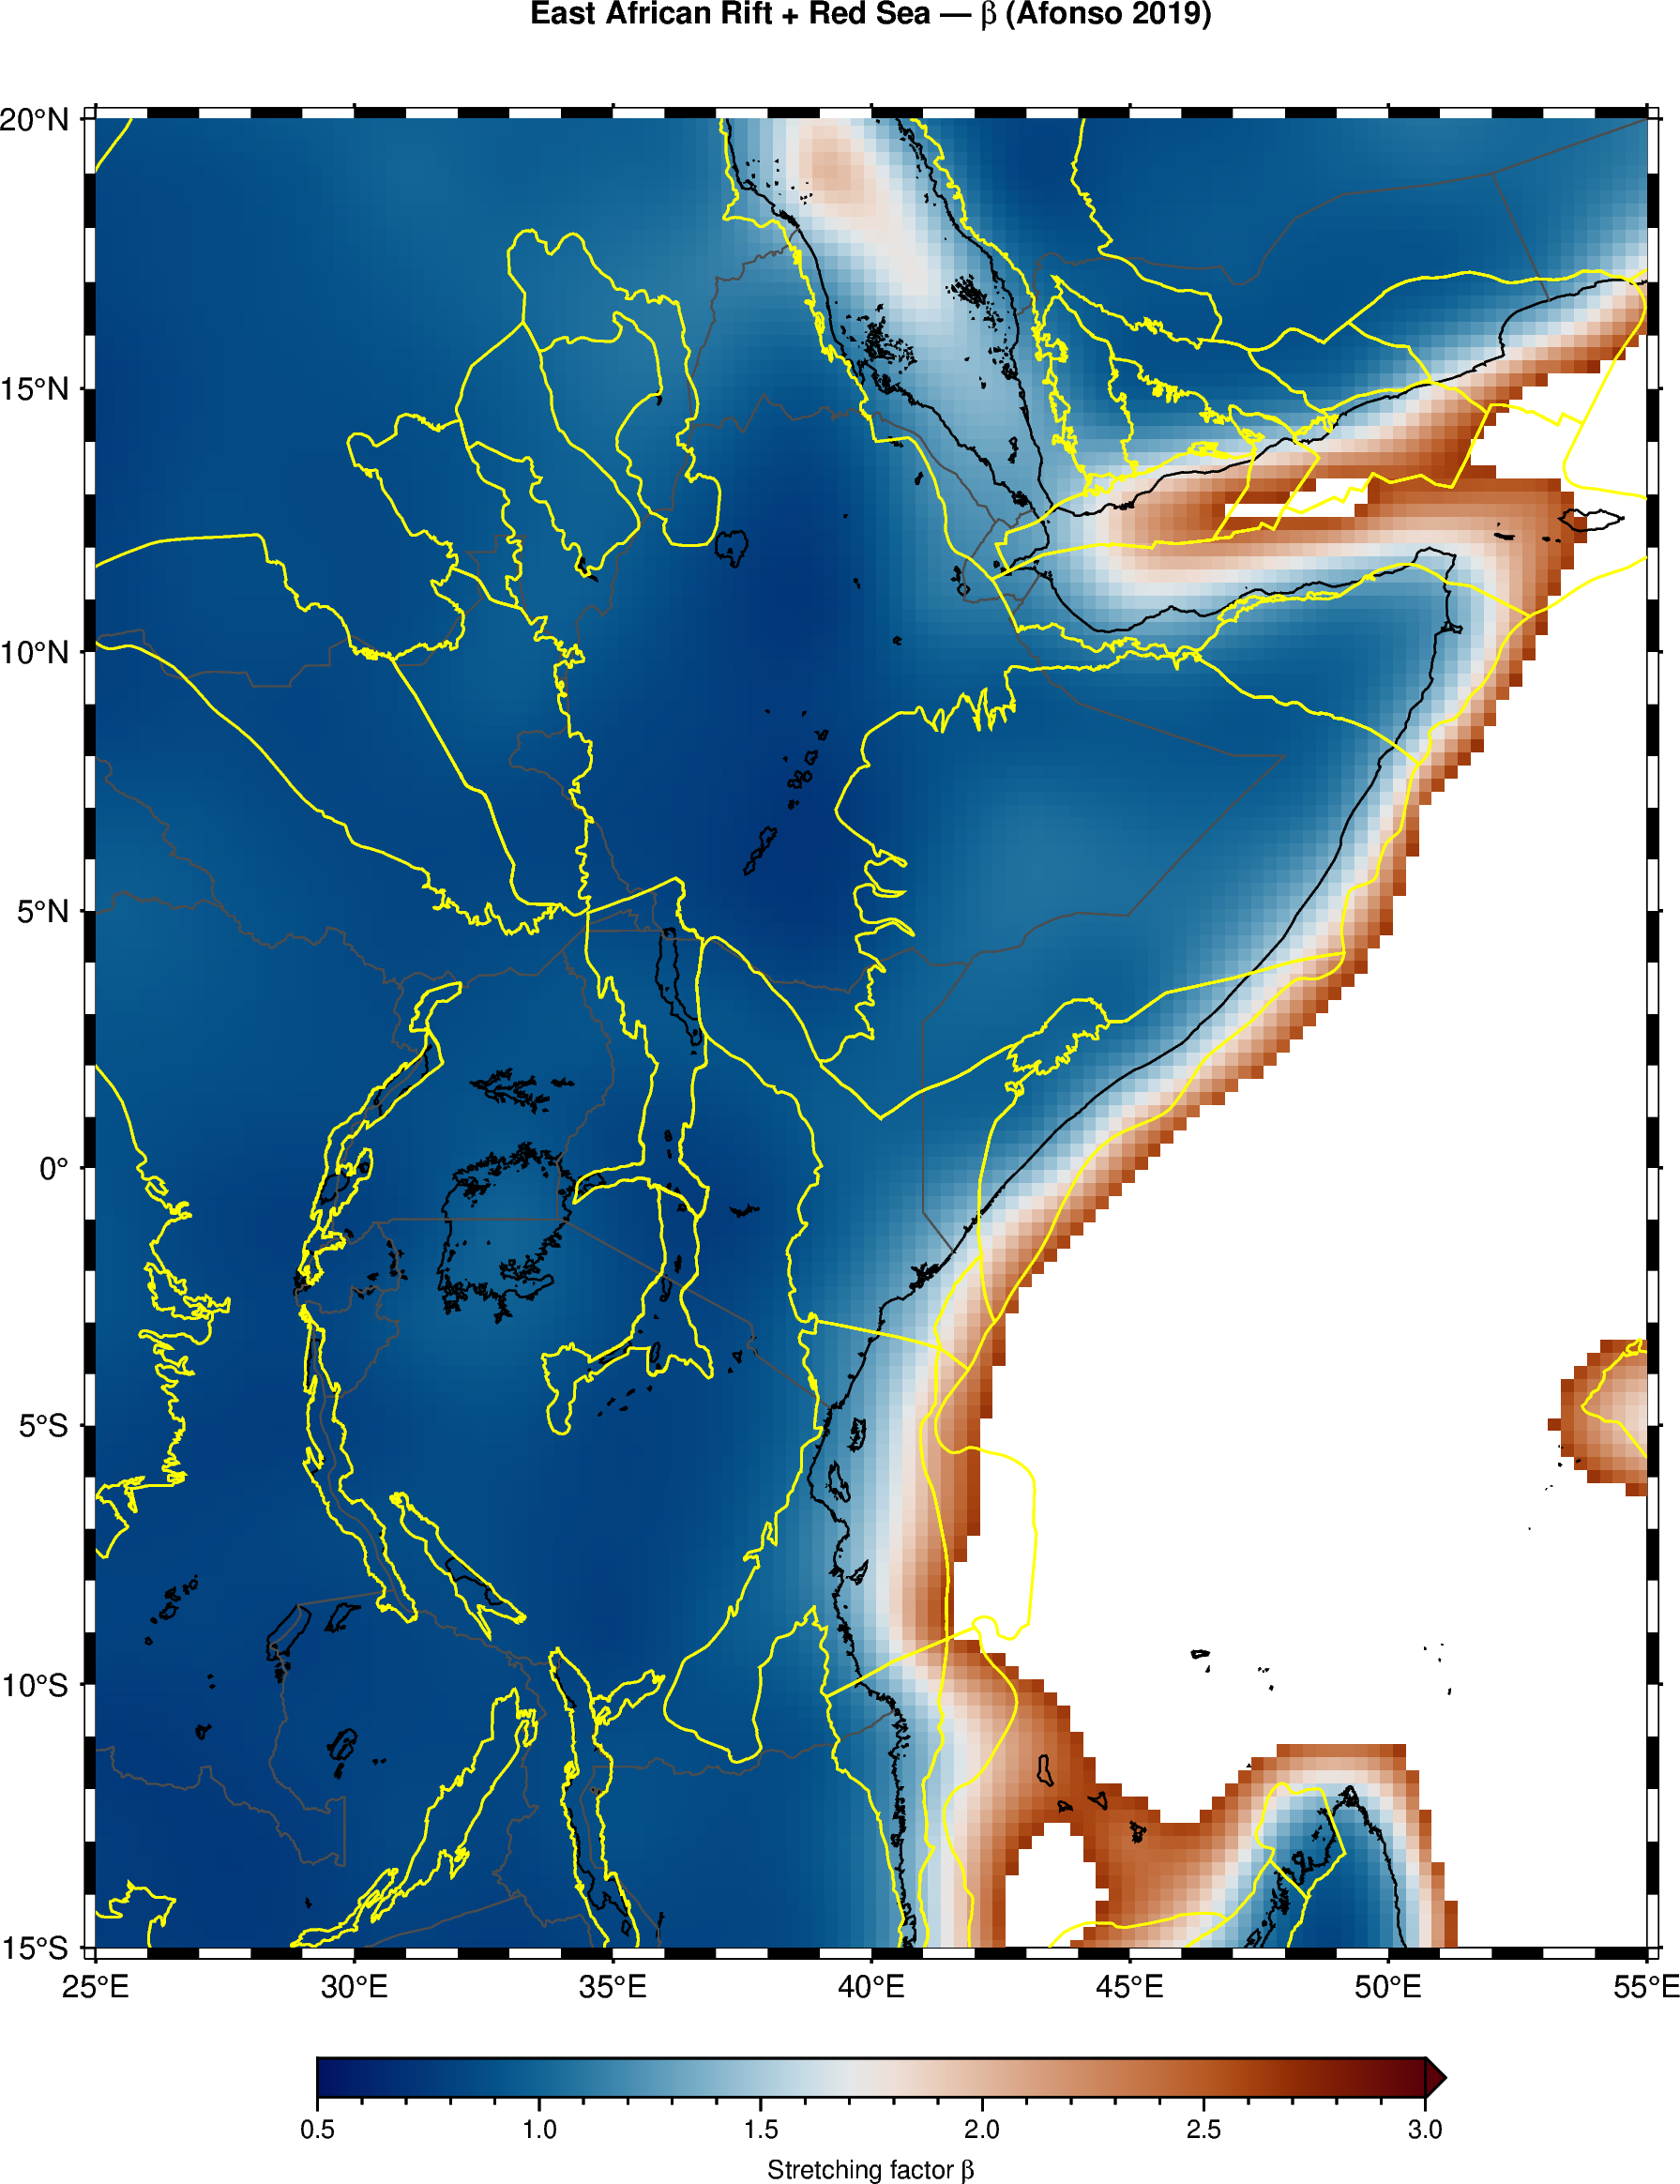

In [6]:
fig = pygmt.Figure()
fig.basemap(region=EARS_REGION, projection=EARS_PROJ,
            frame=["af", "WSne+tEast African Rift + Red Sea — β (Afonso 2019)"])
pygmt.makecpt(cmap="vik", series=[0.5, BETA_CBAR_MAX, 0.1], continuous=True)
fig.grdimage(grid=beta, cmap=True, nan_transparent=True)
fig.coast(shorelines="0.5p,black", borders=["1/0.4p,gray30"])

# Overlay ICONS basins within the region
sub_basins = basins.cx[EARS_REGION[0]:EARS_REGION[1], EARS_REGION[2]:EARS_REGION[3]]
print(f"  ICONS basins in view: {len(sub_basins)}")
for _, row in sub_basins.iterrows():
    g = row.geometry
    if g is None or g.is_empty: continue
    parts = g.geoms if g.geom_type == "MultiPolygon" else [g]
    for part in parts:
        x, y = part.exterior.xy
        fig.plot(x=list(x), y=list(y), pen="0.6p,yellow", close=True)

fig.colorbar(frame=["a0.5f0.1", "x+lStretching factor β"],
             position="JBC+w10c/0.35c+h+o0/1c+ef")
fig.show(width=900)


## 5. Panel D — paleogeographic reconstruction of the high-β footprint

Reconstruct the β field to `PALEO_AGE_MA` via `gplately.Raster.reconstruct`. The high-β cells that today mark passive margins will show up on the paleo-map along the future rift lines of the Pangea supercontinent.

  extracting 96,735 high-β cell centroids for reconstruction
  sub-sampled to 48,368 points for map rendering


  PlatePartitioner ready with 2391 static polygons
  assigning plate IDs to 48368 high-β centroids...


  1 cells on plate 0


  32,817 of 48,368 centroids on paleo-continental crust at 200 Ma  (dropped 15,551 offshore/oceanic)


  paleo β range in map: min=1.50  p50=2.01  p95=2.60  max=2.67


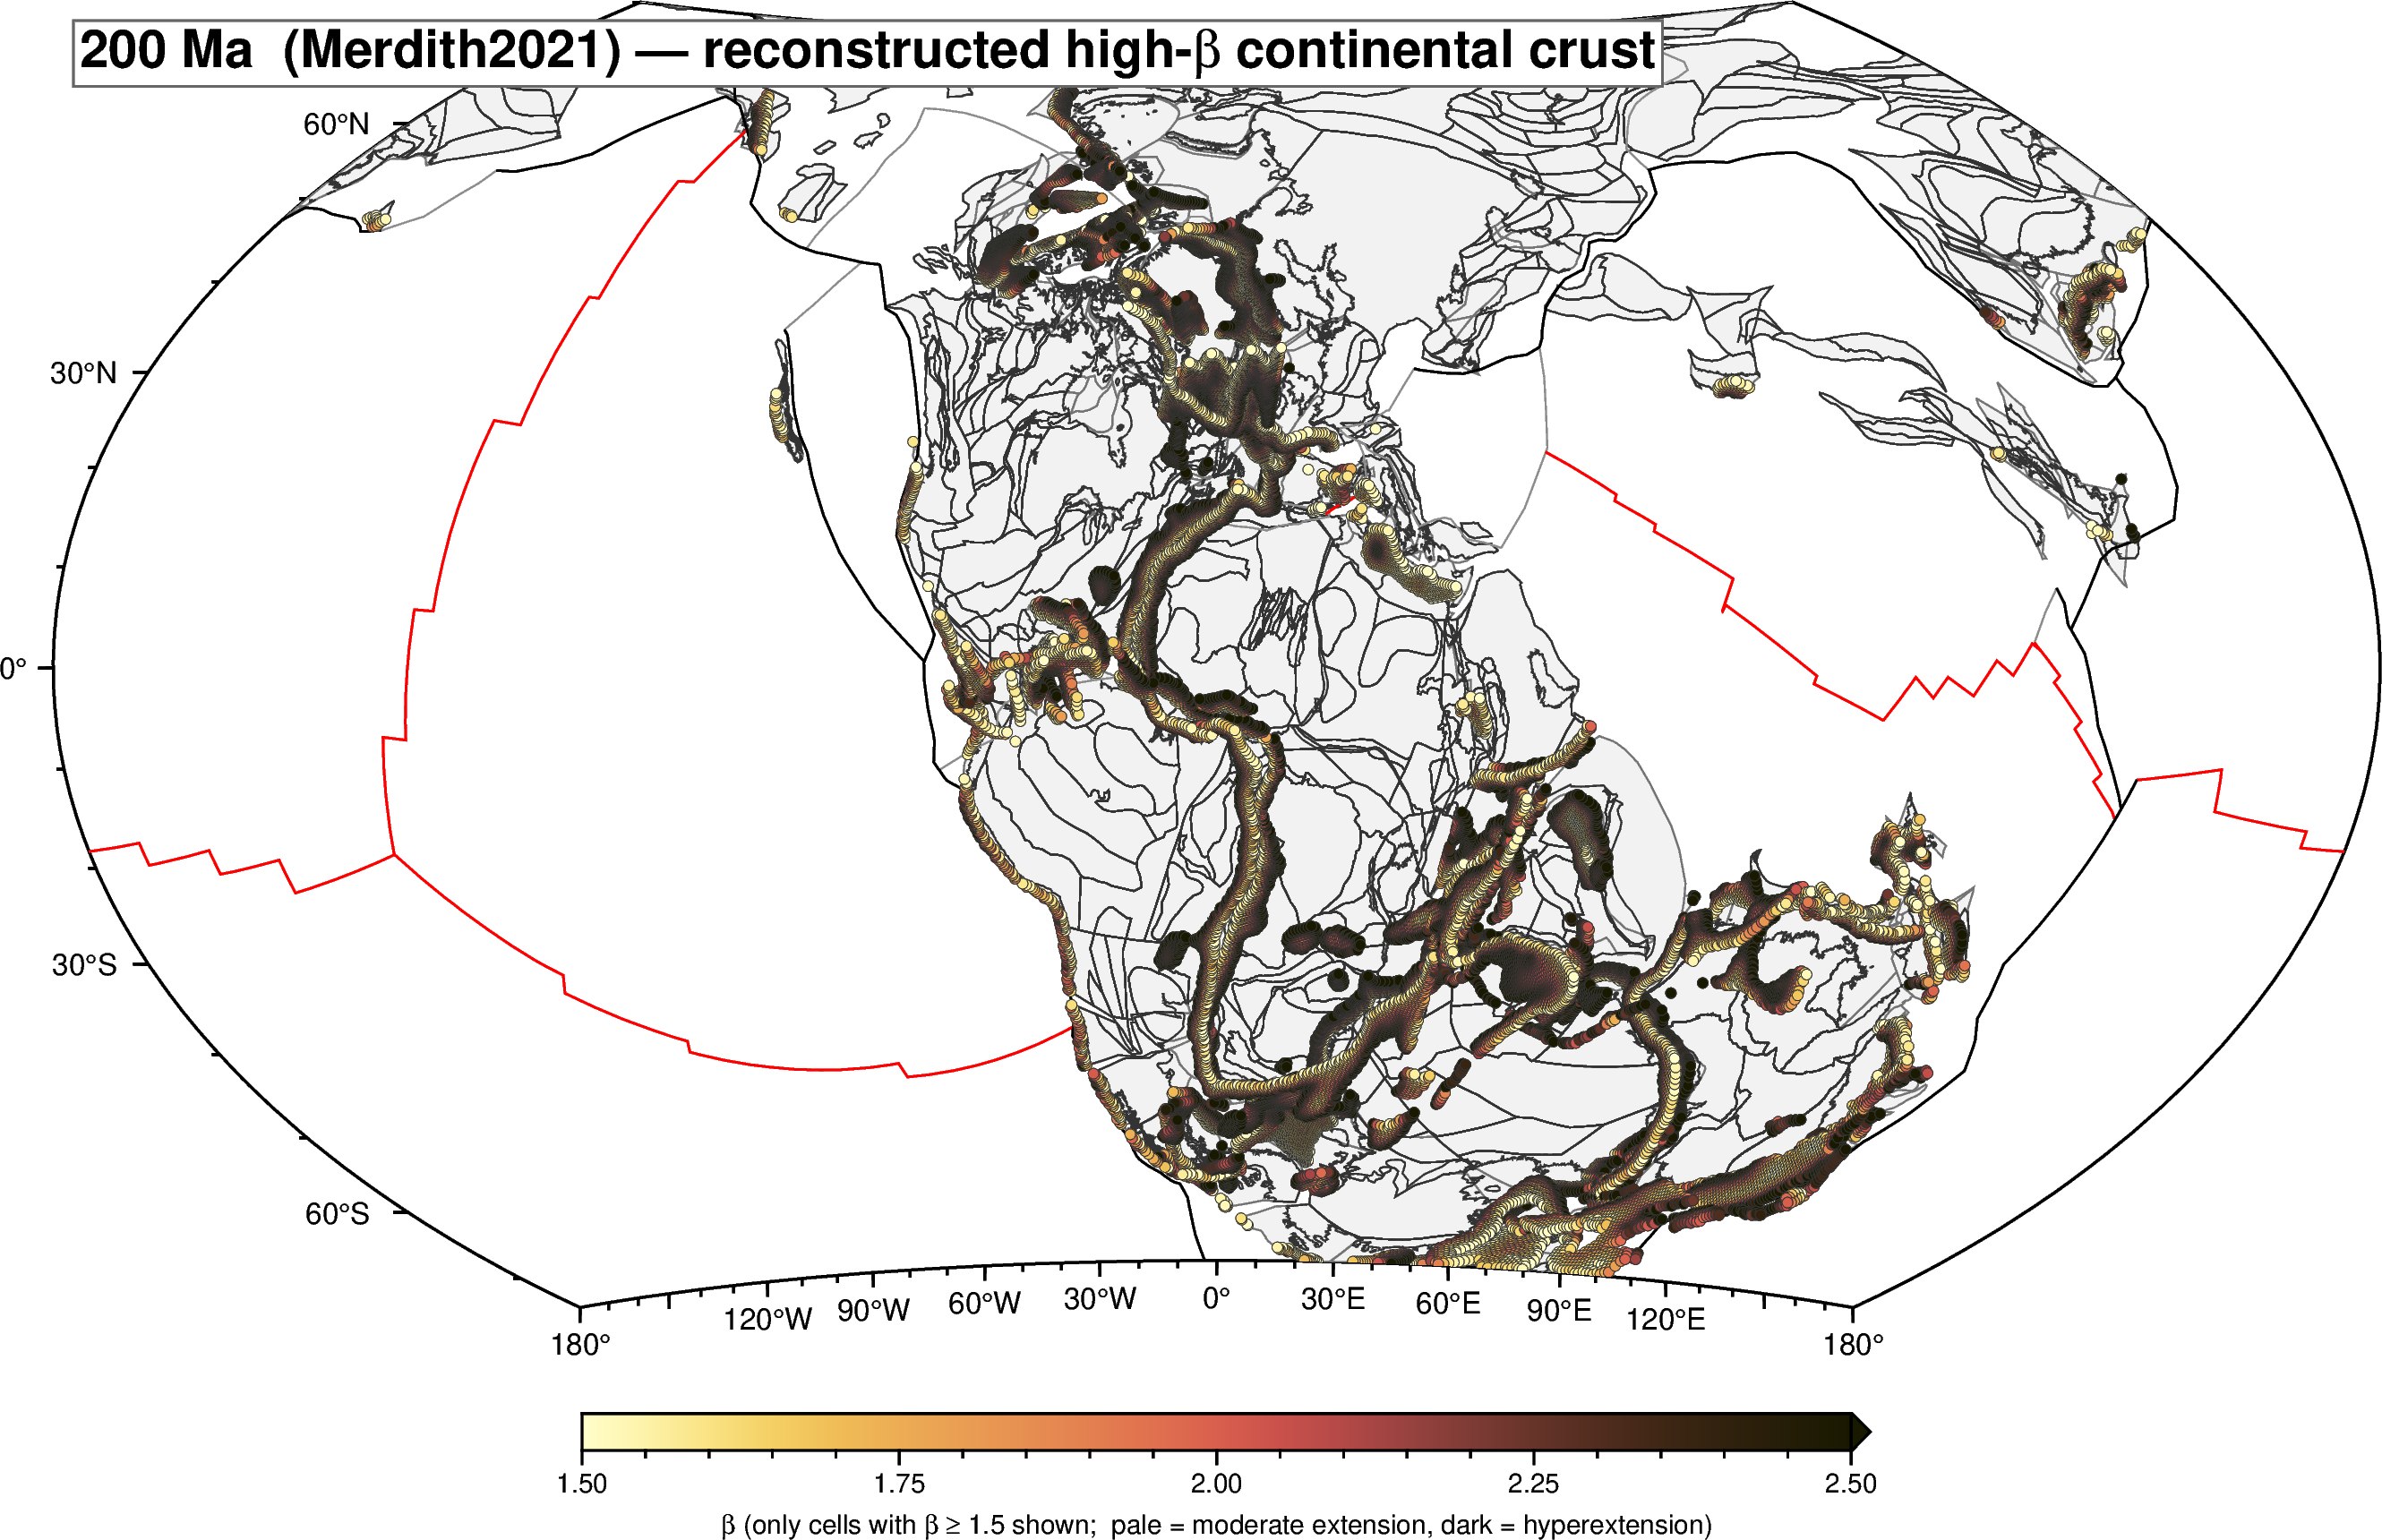

In [7]:
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

# Extract high-β cell CENTROIDS as a point cloud (much more robust for
# reconstruction than raster.reconstruct on a sparse mask — the raster path
# routinely returns an all-NaN grid when only a small fraction of cells carry
# data, because gplately's raster reconstruction resamples to a regular grid
# and the interpolation smears NaNs everywhere).
LON, LAT = np.meshgrid(beta.lon.values, beta.lat.values)
_hi = (beta.values >= BETA_HIGH_THRESHOLD) & np.isfinite(beta.values)
hi_lons = LON[_hi]
hi_lats = LAT[_hi]
hi_beta = beta.values[_hi]
print(f"  extracting {len(hi_lons):,} high-β cell centroids for reconstruction")

# Sub-sample if the point cloud is very dense (>50k points would slow rendering).
if len(hi_lons) > 50_000:
    step = int(np.ceil(len(hi_lons) / 50_000))
    hi_lons, hi_lats, hi_beta = hi_lons[::step], hi_lats[::step], hi_beta[::step]
    print(f"  sub-sampled to {len(hi_lons):,} points for map rendering")

# ----------------------------------------------------------------------------
# Plate-ID assignment — canonical GPlates PlatePartitioner over StaticPolygons.
#
# Merdith 2021 has 850 continental-only polygons but 2391 STATIC polygons that
# cover the entire globe (including rifted-margin and oceanic segments). Using
# ContinentalPolygons alone leaves offshore basins with pid=None — they end
# up either unrotated (visually "floating in the ocean at reconstruction age")
# or forced onto a distant continental terrane by a nearest-boundary fallback.
#
# StaticPolygons + PlatePartitioner is the canonical GPlates approach. Every
# point on Earth resolves to a well-defined plate ID under the Merdith
# rotation model, and offshore basins ride the appropriate margin/oceanic
# plate with the correct paleo-position.
# ----------------------------------------------------------------------------
_static_features = list(pygplates.FeaturesFunctionArgument(
    model.get_static_polygons()).get_features())
_rotation_model  = pygplates.RotationModel(model.get_rotation_model())
_partitioner     = pygplates.PlatePartitioner(_static_features, _rotation_model)
print(f"  PlatePartitioner ready with {len(_static_features)} static polygons")

def assign_plate_ids(lons, lats):
    """Return int array of plate IDs from the Merdith static-polygon
    partition. Any point that fails to partition (extremely rare — poles
    only) gets pid=0 which stays fixed under any rotation."""
    pids = np.zeros(len(lons), dtype=int)
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        pt = pygplates.PointOnSphere(float(lat), float(lon))
        partitioning_plate = _partitioner.partition_point(pt)
        if partitioning_plate is not None:
            pids[i] = int(partitioning_plate.get_feature().get_reconstruction_plate_id())
    return pids

# Assign real plate IDs to every high-β cell centroid (nearest-polygon
# fallback ensures offshore cells get their nearest continental plate,
# not the anchor plate = 0 = stays put in the ocean).
print(f"  assigning plate IDs to {len(hi_lons)} high-β centroids...")
_hi_pids = assign_plate_ids(hi_lons, hi_lats)
print(f"  {int((_hi_pids == 0).sum())} cells on plate 0")

# Reconstruct centroids with explicit plate IDs
gpts = gplately.Points(recon, hi_lons, hi_lats,
                       plate_id=_hi_pids,
                       anchor_plate_id=ANCHOR_PLATE_ID)
plons, plats = gpts.reconstruct(float(PALEO_AGE_MA),
                                return_array=True,
                                anchor_plate_id=ANCHOR_PLATE_ID)
paleo_df = pd.DataFrame({"paleo_lon": plons, "paleo_lat": plats, "beta": hi_beta})
paleo_df = paleo_df.dropna(subset=["paleo_lon", "paleo_lat"])

# ---- Drop cells that land in the open ocean at this age ----
# (β values sampled on today's grid can reconstruct to oceanic paleo-crust;
# those dots read as "reconstruction failed" over blue ocean. Restrict to
# points inside a reconstructed continental polygon.)
_cont_recon_at_age = []
_cf = list(pygplates.FeaturesFunctionArgument(
    model.get_layer("ContinentalPolygons")).get_features())
_rr = []
pygplates.reconstruct(_cf, _rotation_model, _rr, float(PALEO_AGE_MA),
                      anchor_plate_id=ANCHOR_PLATE_ID)
for _r in _rr:
    _g = _r.get_reconstructed_geometry()
    if isinstance(_g, pygplates.PolygonOnSphere):
        _cont_recon_at_age.append(_g)
_on_land = np.zeros(len(paleo_df), dtype=bool)
for _i, (_lo, _la) in enumerate(zip(paleo_df["paleo_lon"].to_numpy(),
                                     paleo_df["paleo_lat"].to_numpy())):
    _pt = pygplates.PointOnSphere(float(_la), float(_lo))
    for _pg in _cont_recon_at_age:
        if _pg.is_point_in_polygon(_pt):
            _on_land[_i] = True; break
_n_off = int((~_on_land).sum())
paleo_df = paleo_df.loc[_on_land].copy()
print(f"  {len(paleo_df):,} of {len(hi_lons):,} centroids on paleo-continental "
      f"crust at {PALEO_AGE_MA:.0f} Ma  (dropped {_n_off:,} offshore/oceanic)")

gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines"),
    continents=model.get_layer("ContinentalPolygons"),
    plot_engine=gplately.PygmtPlotEngine(),
    time=float(PALEO_AGE_MA),
    anchor_plate_id=ANCHOR_PLATE_ID,
)

fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
gplot.plot_continents(fig, fill="gray95", pen="0.4p,gray45")
gplot.plot_coastlines(fig, pen="0.4p,gray20")
try:
    gplot.plot_all_topological_sections(fig, pen="0.4p,gray55")
    gplot.plot_ridges(fig, pen="0.6p,red")
    gplot.plot_trenches(fig, pen="0.6p,black")
except Exception as _e:
    print(f"  topology overlay skipped: {_e}")

# High-β cells as small coloured dots. CPT retargeted to the ACTUAL data
# range of the >=1.5 subset. With the relaxed t_c > 12 km cutoff (cell 6),
# the hyperextended tail reaches β ≈ 2.67 (Iberia-Newfoundland, Woodlark,
# Afar), but the bulk of the >=1.5 population sits between 1.5 and 2.0. A
# tight [1.5, 2.5] palette with +ef overflow arrow gives contrast across
# the whole population instead of squashing everything at the low end.
_paleo_beta = paleo_df["beta"].to_numpy()
_p50 = float(np.percentile(_paleo_beta, 50))
_p95 = float(np.percentile(_paleo_beta, 95))
_pmx = float(_paleo_beta.max())
print(f"  paleo β range in map: min={_paleo_beta.min():.2f}  p50={_p50:.2f}  "
      f"p95={_p95:.2f}  max={_pmx:.2f}")

pygmt.makecpt(cmap="lajolla", series=[BETA_HIGH_THRESHOLD, 2.5, 0.05],
              continuous=True, reverse=True)
xyz = np.column_stack([
    paleo_df["paleo_lon"].to_numpy(),
    paleo_df["paleo_lat"].to_numpy(),
    paleo_df["beta"].to_numpy(),
])
fig.plot(data=xyz, style="c0.10c", cmap=True, pen="0.15p,gray20")

fig.colorbar(frame=["a0.25f0.05",
                    f"x+lβ (only cells with β ≥ {BETA_HIGH_THRESHOLD} shown;  "
                    f"pale = moderate extension, dark = hyperextension)"],
             position="JBC+w12c/0.35c+h+o0/1c+ef")
fig.text(text=f"{PALEO_AGE_MA:.0f} Ma  ({MODEL_NAME}) — reconstructed high-β continental crust",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


### How to read the paleogeographic β map

Only cells with present-day β ≥ `BETA_HIGH_THRESHOLD` are shown. These are the modern crustal-thinning footprints, mostly passive margins around the Atlantic (both sides), around Africa (west + east), around India + Australia, and the East African + Red Sea active rift. Reconstructed to 200 Ma, they cluster along the **future** rift lines of Pangea:

- The **Central Atlantic Magmatic Province** margin (eastern USA / NW Africa / NE South America) shows as one continuous high-β strip along the future Central Atlantic opening line.
- The **South Atlantic** conjugate margins (South America / West Africa) hug a linear high-β corridor.
- The **Karoo-Ferrar** related southern-Gondwana rifted margins (India / East Antarctica / Australia) light up as high-β.
- East African + Red Sea Rift high-β cells reconstruct to interior northern Africa — but at 200 Ma this rifting hadn't started yet, so those cells will look anachronistic (compare against T69 for gateway-opening chronology).

The plot is a strong visual case for **crustal-thickness archives being an important paleo-tectonic record** — the imprint of ancient rifting is preserved in the modern crustal-thickness field, and the same plate model that predicts today's continental configuration also predicts where those imprints originated.

## Extend this

- **Sweep the paleo age.** Loop `PALEO_AGE_MA` ∈ [0, 20, 40, ..., 300] and animate the reconstruction. Watch high-β cells cluster into rift precursors and then disperse as breakup progresses.
- **Two-layer stretching model.** Compute the mantle-lithosphere stretching factor δ from the crustal-thickness β, assuming pure-shear or Rowley-Xie style depth-dependent stretching. Compare crust vs mantle β to identify hyper-extended margins.
- **Volumetric β integration.** Multiply β by cell area to compute the total volume of stretched crust globally. Split by SUB_REGIME from T53's basin classification.
- **Cross-reference with the plate-model rift history.** Overlay T14 (rift obliquity through time) segments at each snapshot. High-β cells should coincide with T14's rift segments.
- **Include Moho depth.** Afonso 2019 also provides Moho depth — replace `T_C0_KM` with the reference depth to get β' from Moho instead of crustal thickness. Different reference gives different β for the same physical crust.

## Related notebooks

- **T53** — ICONS basin inventory (sibling). Uses the same crustal-thickness grid but from the basin-per-region perspective; T54 is the raster-based view.
- **T14** — Rift obliquity through time (Brune-based). Uses plate topologies rather than crustal thickness, but the same underlying continental-extension process is what T54 records the imprint of.
- **T31** — Dynamic topography change in deep time. Complementary rate-based field on the same paleo maps.

## References

- Heine, C. (2007). Formation and Evolution of Intracontinental Sedimentary Basins. PhD thesis, EarthByte Group, University of Sydney.
- Heine, C. & Müller, R.D. (2008). The IntraCONtinental basinS (ICONS) atlas — applications in eastern Australia. In: Blevin, J.E., Bradshaw, B.E. & Uruski, C. (Eds), *Eastern Australasian Basins Symposium III*, Petroleum Exploration Society of Australia, Special Publication, 275-290.
- Heine, C., Müller, R.D., Steinberger, B. & Torsvik, T.H. (2008). Subsidence in intracontinental basins due to dynamic topography. *Physics of the Earth and Planetary Interiors* 171(1-4), 252-264. doi:10.1016/j.pepi.2008.05.008.
- Heine, C., Zoethout, J., & Müller, R.D. (2013). Kinematics of the South Atlantic rift. *Solid Earth* 4, 215-253. https://doi.org/10.5194/se-4-215-2013
- Afonso, J.C., Salajegheh, F., Szwillus, W., Ebbing, J., & Gaina, C. (2019). A global reference model of the lithosphere and upper mantle from joint inversion and analysis of multiple data sets. *Geophysical Journal International* 217(3), 1602-1628. https://doi.org/10.1093/gji/ggz094
- McKenzie, D. (1978). Some remarks on the development of sedimentary basins. *Earth and Planetary Science Letters* 40(1), 25-32.
- Mather, B.R., Müller, R.D., Zahirovic, S., et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Merdith, A.S., et al. (2021). Extending full-plate tectonic models into deep time. *Earth-Science Reviews* 214, 103477. https://doi.org/10.1016/j.earscirev.2020.103477
